In [1]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

from tensorflow import keras
from keras import layers
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.regularizers import l2
from keras.applications.resnet import preprocess_input
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from google.colab import drive

#install drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

BASE_PATH = "/content/drive/MyDrive/CrossValidation/Vgg16DensenetOPT"
TRAIN_DIR = "/content/drive/MyDrive/kaggle/train"
TEST_DIR = "/content/drive/MyDrive/kaggle/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
N_SPLITS = 3
SEED = 42
THRESHOLD = 0.5

folders = [
    "models",
    "histories",
    "metrics",
    "plots/training",
    "plots/confusion_matrix",
    "plots/roc",
    "plots/metrics"
]

for f in folders:
    os.makedirs(os.path.join(BASE_PATH, f), exist_ok=True)

print(BASE_PATH)
print(os.listdir("/content/drive/MyDrive"))
print(os.listdir(BASE_PATH))

#load files and label
class_names = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

print("Class:", class_names)

filepaths = []
labels = []

for idx, class_name in enumerate(class_names):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = sorted([
        os.path.join(class_dir, f)
        for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    filepaths.extend(files)
    labels.extend([idx] * len(files))

filepaths = np.array(filepaths)
labels = np.array(labels)

print("Total images:", len(filepaths))
print("Label distribution:", {class_names[i]: int((labels == i).sum()) for i in range(len(class_names))})

#data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
], name="data_augmentation")

#build model
def build_model(model_name):
    if model_name == "vgg16":
        base_model = keras.applications.VGG16(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
    elif model_name == "densenet":
        base_model = keras.applications.DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
    else:
        raise ValueError("model_name must be 'vgg16' or 'densenet'")

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

#dataset funcions
def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = img / 255.0
    label = tf.cast(label, tf.float32)
    return img, label


def augment_data(img, label):
    img = data_augmentation(img, training=True)
    return img, label


def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

#evaluations functions
def evaluate_model(model, dataset):
    y_true = []
    y_pred = []

    for x, y in dataset:
        preds = model(x, training=False).numpy()
        y_true.extend(y.numpy())
        y_pred.extend(preds.flatten())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_bin = (y_pred > THRESHOLD).astype(int)

    cm = confusion_matrix(y_true, y_bin)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    auc = roc_auc_score(y_true, y_pred)

    return {
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "auc": auc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }


/content/drive/MyDrive/CrossValidation/Vgg16DensenetOPT
['Colab Notebooks', 'kaggle', 'results5', 'results10', 'resultsResnetOPT1', 'resultsVgg16DensenetOPT1', 'GradCam', 'materiali tesi vari', 'CrossValidation', 'Sacilotto Greta Tesi Triennaleee.docx']
['models', 'histories', 'metrics', 'plots']
Class: ['benign', 'malignant']
Total images: 2637
Label distribution: {'benign': 1440, 'malignant': 1197}


In [ ]:
# 3-FOLD CV LOOP

models_to_run = ["vgg16", "densenet"]
all_results = {}

for model_name in models_to_run:
    print("\n" + "="*70)
    print(f"3-FOLD CROSS VALIDATION - {model_name.upper()}")
    print("="*70)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    fold_histories = {}
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(filepaths, labels), start=1):
        print("\n" + "-"*60)
        print(f"Training {model_name} - Fold {fold}/{N_SPLITS}")
        print("-"*60)

        tf.keras.backend.clear_session()

        X_train, X_val = filepaths[train_idx], filepaths[val_idx]
        y_train, y_val = labels[train_idx], labels[val_idx]

        print(f"Train samples: {len(X_train)}")
        print(f"Validation samples: {len(X_val)}")

        train_ds_fold = make_dataset(X_train, y_train, training=True)
        val_ds_fold = make_dataset(X_val, y_val, training=False)

        model = build_model(model_name)

        checkpoint_path = os.path.join(BASE_PATH, "models", f"{model_name}_fold{fold}_best.keras")
        history_path = os.path.join(BASE_PATH, "histories", f"{model_name}_fold{fold}_history.json")

        checkpoint = ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        )

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        )

        reduce_lr = ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )

        history = model.fit(
            train_ds_fold,
            validation_data=val_ds_fold,
            epochs=EPOCHS,
            callbacks=[checkpoint, early_stopping, reduce_lr]
        )

        with open(history_path, "w") as f:
            json.dump(history.history, f, indent=4)

        fold_histories[f"fold_{fold}"] = history.history

        best_model = keras.models.load_model(checkpoint_path)
        metrics = evaluate_model(best_model, val_ds_fold)
        metrics["fold"] = fold
        metrics["n_train"] = len(X_train)
        metrics["n_val"] = len(X_val)

        fold_results.append(metrics)

        print(f"\nFold {fold} metrics:")
        print(metrics)

    #save results per model

    fold_results_df = pd.DataFrame(fold_results)
    fold_results_df = fold_results_df[
        ["fold", "n_train", "n_val", "accuracy", "sensitivity", "specificity", "f1", "auc", "tn", "fp", "fn", "tp"]
    ]

    metrics_csv_path = os.path.join(BASE_PATH, "metrics", f"{model_name}_3fold_cv_results.csv")
    fold_results_df.to_csv(metrics_csv_path, index=False)

    summary_df = fold_results_df[["accuracy", "sensitivity", "specificity", "f1", "auc"]].agg(["mean", "std"])
    summary_path = os.path.join(BASE_PATH, "metrics", f"{model_name}_3fold_cv_summary.csv")
    summary_df.to_csv(summary_path)

    print("\nSaved fold results to:", metrics_csv_path)
    print("\nSaved summary to:", summary_path)
    print(summary_df)



3-FOLD CROSS VALIDATION - VGG16

------------------------------------------------------------
Training vgg16 - Fold 1/3
------------------------------------------------------------
Train samples: 1758
Validation samples: 879
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.6697 - loss: 0.8436
Epoch 1: val_loss improved from None to 0.73343, saving model to /content/drive/MyDrive/CrossValidation/Vgg16DensenetOPT/models/vgg16_fold1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CrossValidation/Vgg16DensenetOPT/models/vgg16_fold1_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.7366 - loss: 0.7113 - val_accuracy: 0.5700 - val_loss: 0.7334 - learning_rate: 0.0010
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.8077 - loss: 0.5676
Epoch 2: val_loss improved from 0.73343 to 0.69840, saving model to /content/drive/MyDrive/CrossValidation/Vgg16DensenetOPT/models/vgg16_fo

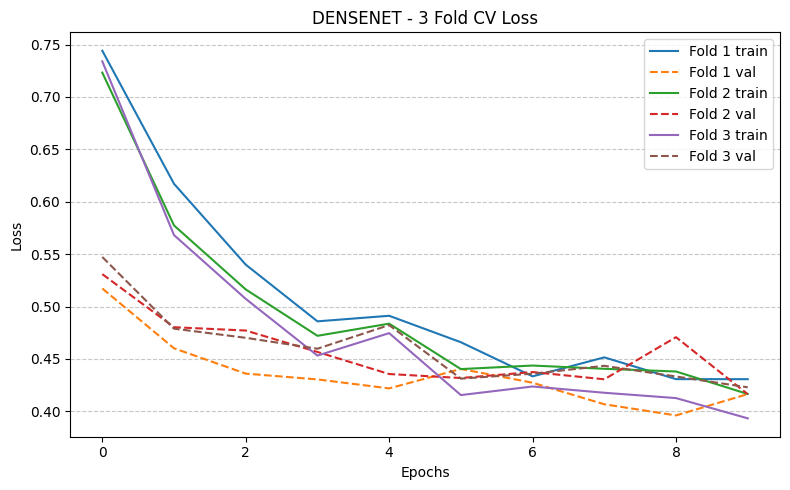

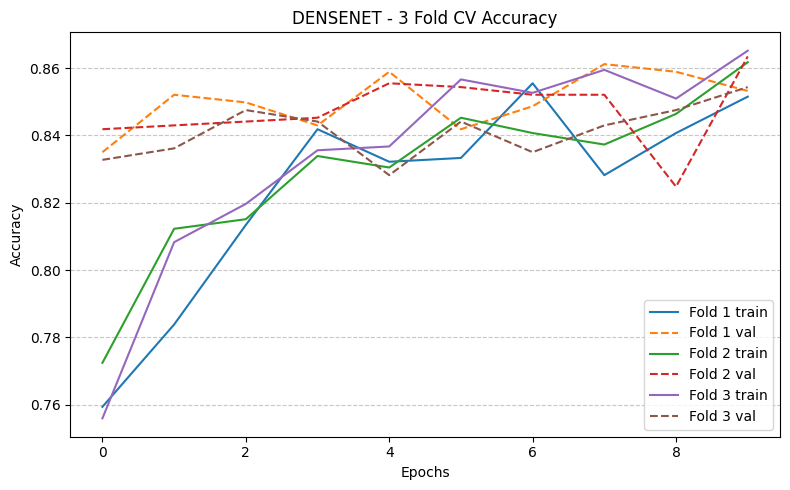

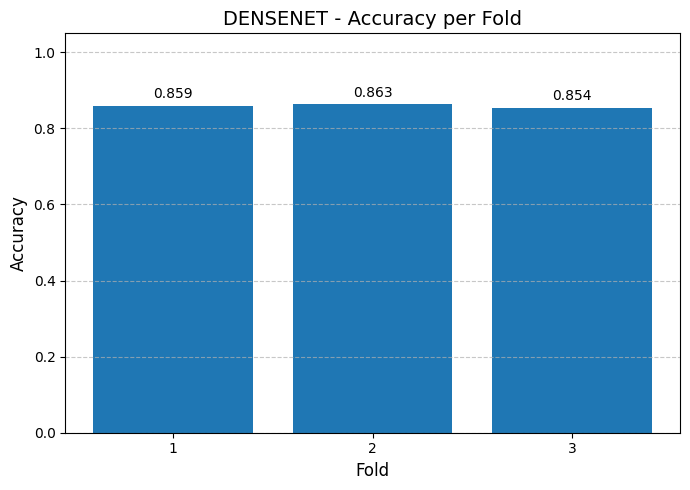

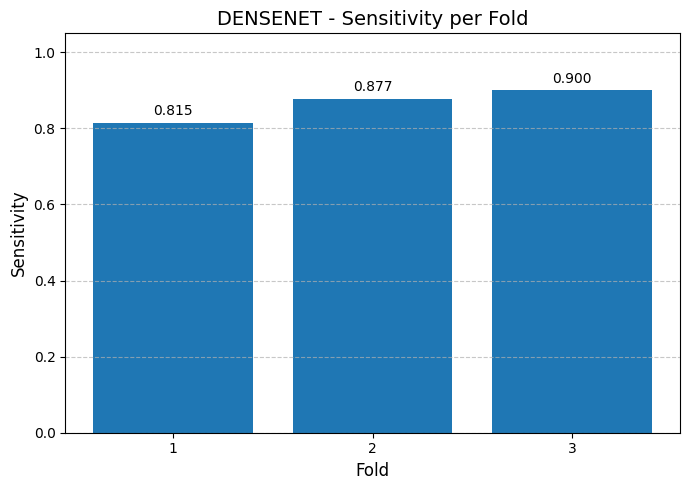

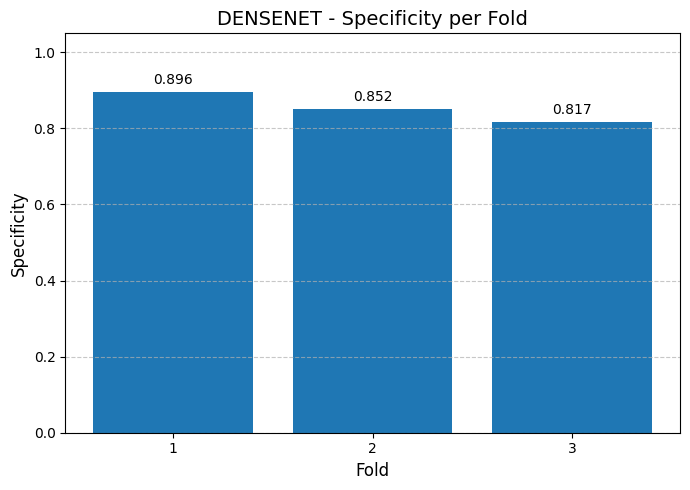

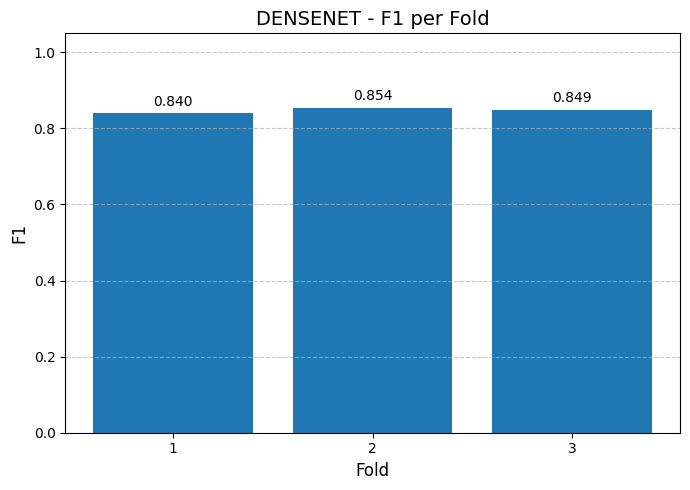


DONE: 3-fold cross validation completed for VGG16 and DenseNet.


In [ ]:

    #plots: loss and accuracy

    plt.figure(figsize=(8, 5))
    for fold in range(1, N_SPLITS + 1):
        h = fold_histories[f"fold_{fold}"]
        plt.plot(h["loss"], label=f"Fold {fold} train")
        plt.plot(h["val_loss"], linestyle="--", label=f"Fold {fold} val")
    plt.title(f"{model_name.upper()} - 3 Fold CV Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    loss_plot_path = os.path.join(BASE_PATH, "plots", "training", f"{model_name}_3fold_loss.png")
    plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(8, 5))
    for fold in range(1, N_SPLITS + 1):
        h = fold_histories[f"fold_{fold}"]
        plt.plot(h["accuracy"], label=f"Fold {fold} train")
        plt.plot(h["val_accuracy"], linestyle="--", label=f"Fold {fold} val")
    plt.title(f"{model_name.upper()} - 3 Fold CV Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    acc_plot_path = os.path.join(BASE_PATH, "plots", "training", f"{model_name}_3fold_accuracy.png")
    plt.savefig(acc_plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


    # PLOT METRIC COMPARISON


    metrics_list = ["accuracy", "sensitivity", "specificity", "f1"]
    os.makedirs(os.path.join(BASE_PATH, "plots", "metrics"), exist_ok=True)

    for metric in metrics_list:
        plt.figure(figsize=(7, 5))
        bars = plt.bar(fold_results_df["fold"].astype(str), fold_results_df[metric])

        plt.title(f"{model_name.upper()} - {metric.capitalize()} per Fold", fontsize=14)
        plt.xlabel("Fold", fontsize=12)
        plt.ylabel(metric.capitalize(), fontsize=12)
        plt.ylim(0, 1.05)
        plt.grid(axis="y", linestyle="--", alpha=0.7)

        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.02,
                f"{height:.3f}",
                ha="center",
                fontsize=10
            )

        plt.tight_layout()
        save_path = os.path.join(BASE_PATH, "plots", "metrics", f"{model_name}_{metric}_comparison.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    # SAVE ALL HISTORIES

    combined_history_path = os.path.join(BASE_PATH, "histories", f"{model_name}_3fold_all_histories.json")
    with open(combined_history_path, "w") as f:
        json.dump(fold_histories, f, indent=4)

    all_results[model_name] = {
        "fold_results": fold_results_df,
        "summary": summary_df
    }

print("\nDONE: 3-fold cross validation completed for VGG16 and DenseNet.")

TABELLA COMPLETA DEI RISULTATI


,model,fold,accuracy,sensitivity,specificity,f1,auc,n_train,n_val,tn,fp,fn,tp
0,vgg16,1,0.8134,0.7118,0.8979,0.7760,0.9106,1758,879,431,49,115,284
1,vgg16,2,0.8350,0.8947,0.7854,0.8312,0.9103,1758,879,377,103,42,357
2,vgg16,3,0.8248,0.8772,0.7812,0.8197,0.9118,1758,879,375,105,49,350
3,densenet,1,0.8589,0.8145,0.8958,0.8398,0.9415,1758,879,430,50,74,325
4,densenet,2,0.8635,0.8772,0.8521,0.8537,0.9345,1758,879,409,71,49,350
5,densenet,3,0.8544,0.8997,0.8167,0.8487,0.9332,1758,879,392,88,40,359
6,resnet,1,0.8521,0.8797,0.8292,0.8438,0.9371,1758,879,398,82,48,351
7,resnet,2,0.8919,0.8947,0.8896,0.8826,0.9568,1758,879,427,53,42,357
8,resnet,3,0.8919,0.9173,0.8708,0.8851,0.9608,1758,879,418,62,33,366


TABELLA RIASSUNTIVA DELLE MEDIE


,accuracy,sensitivity,specificity,f1,auc
model,,,,,
vgg16,0.8244,0.8279,0.8215,0.8089,0.9109
densenet,0.8589,0.8638,0.8549,0.8474,0.9364
resnet,0.8786,0.8972,0.8632,0.8705,0.9516


TABELLA MEDIA E DEVIAZIONE STANDARD


accuracy         sensitivity         specificity              f1  \
             mean     std        mean     std        mean     std    mean   
model                                                                       
vgg16      0.8244  0.0108      0.8279  0.1009      0.8215  0.0662  0.8089   
densenet   0.8589  0.0046      0.8638  0.0442      0.8549  0.0397  0.8474   
resnet     0.8786  0.0230      0.8972  0.0189      0.8632  0.0309  0.8705   

                     auc          
             std    mean     std  
model                             
vgg16     0.0291  0.9109  0.0008  
densenet  0.0070  0.9364  0.0045  
resnet    0.0232  0.9516  0.0127

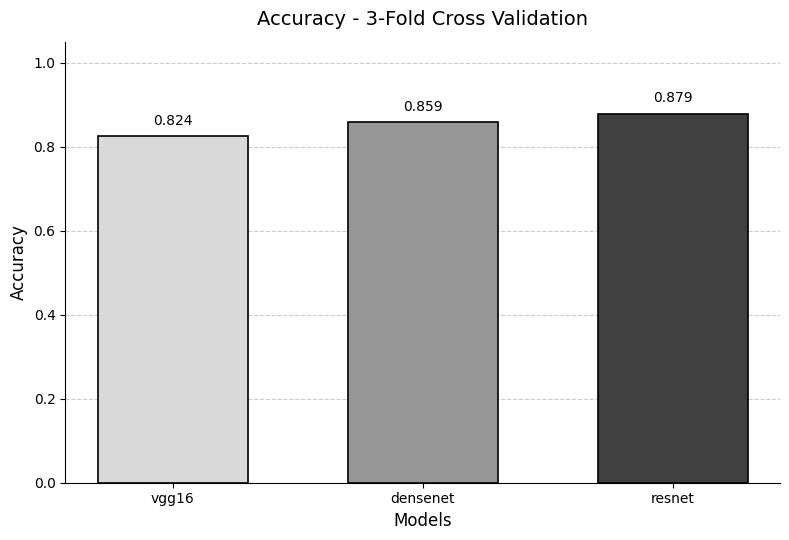

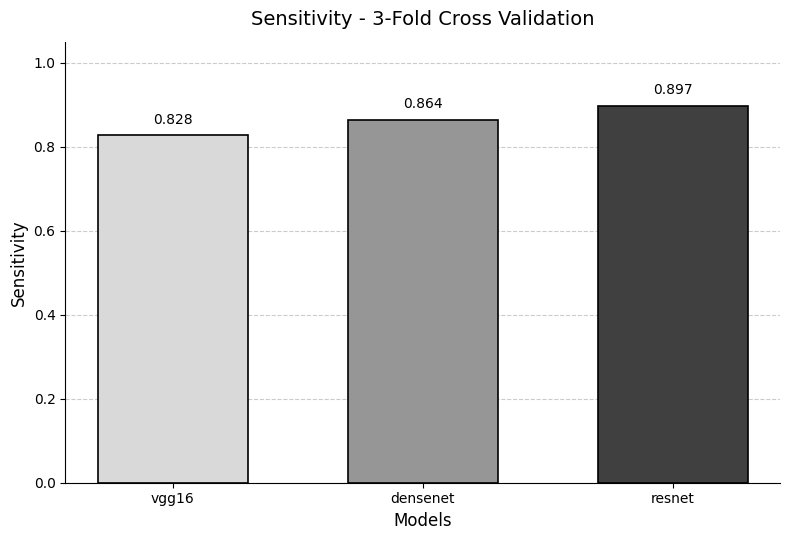

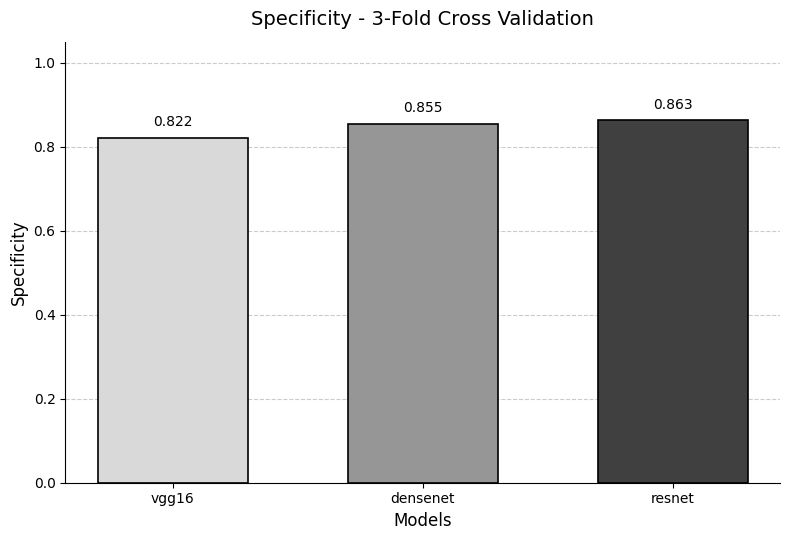

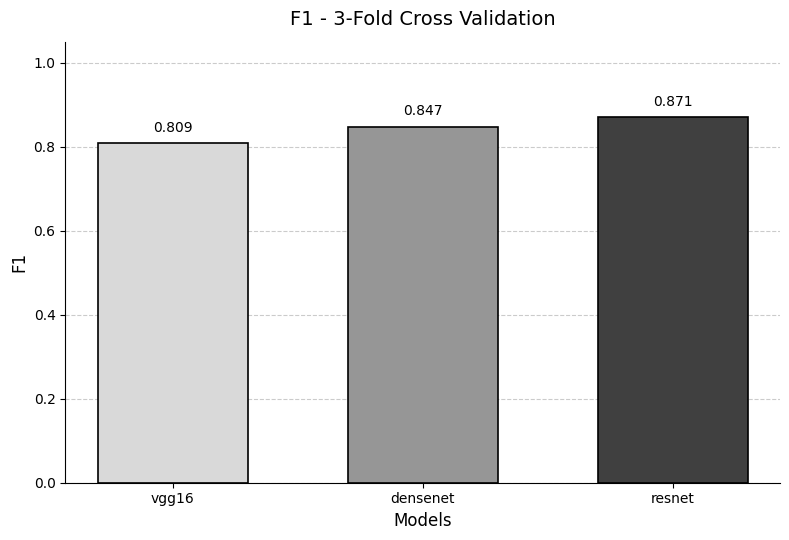

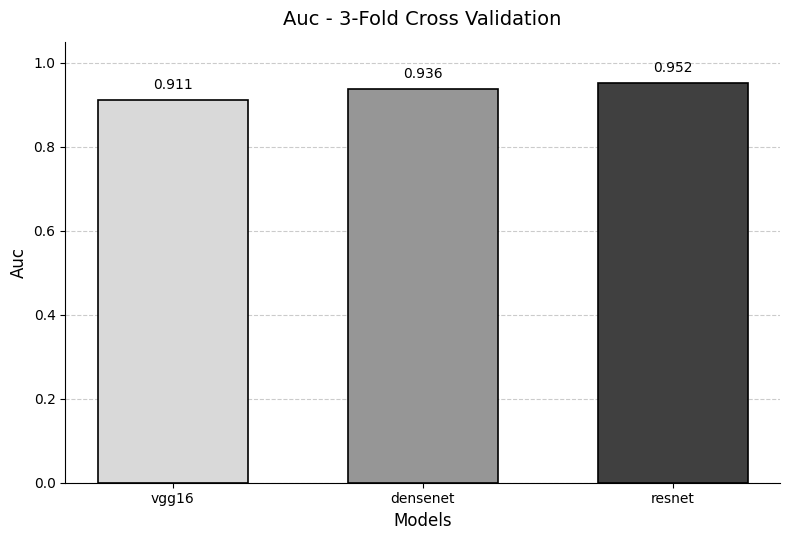

/tmp/ipykernel_640/3828885315.py:253: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


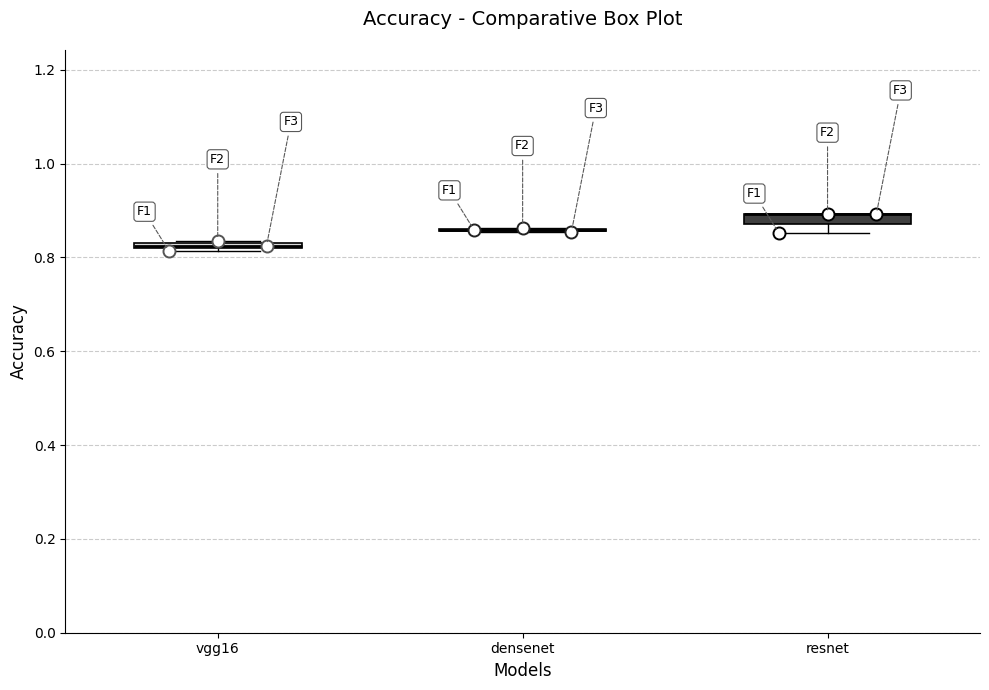

/tmp/ipykernel_640/3828885315.py:253: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


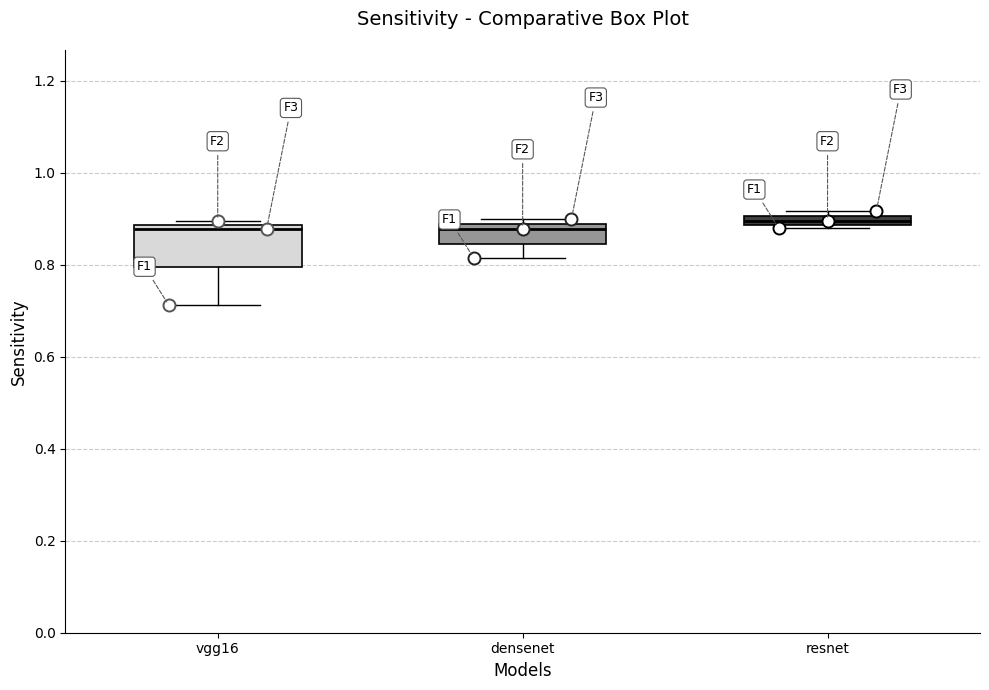

/tmp/ipykernel_640/3828885315.py:253: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


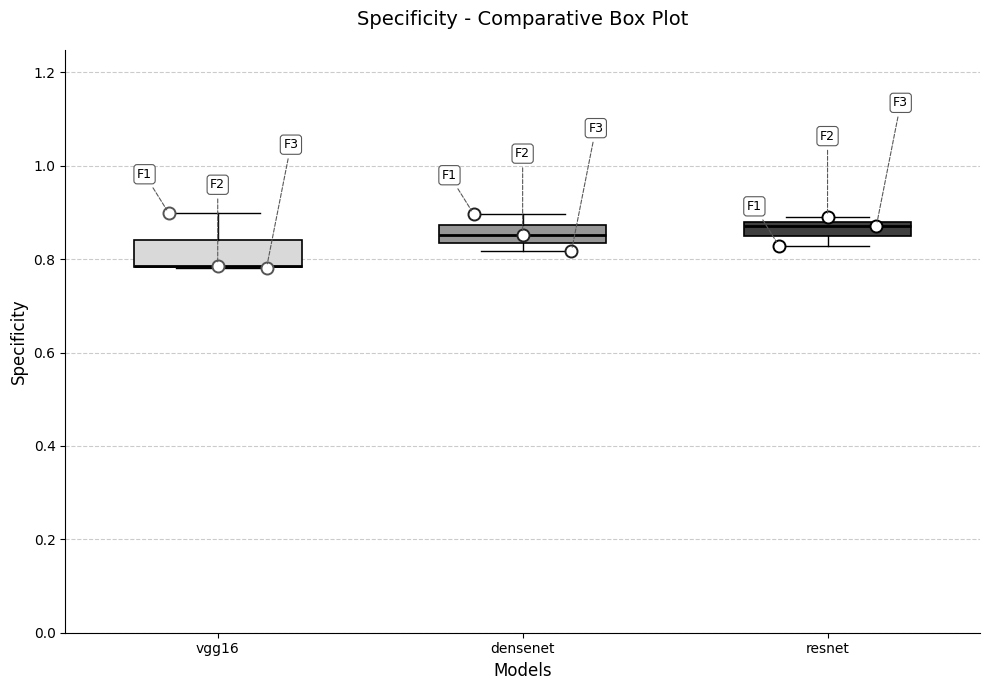

/tmp/ipykernel_640/3828885315.py:253: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


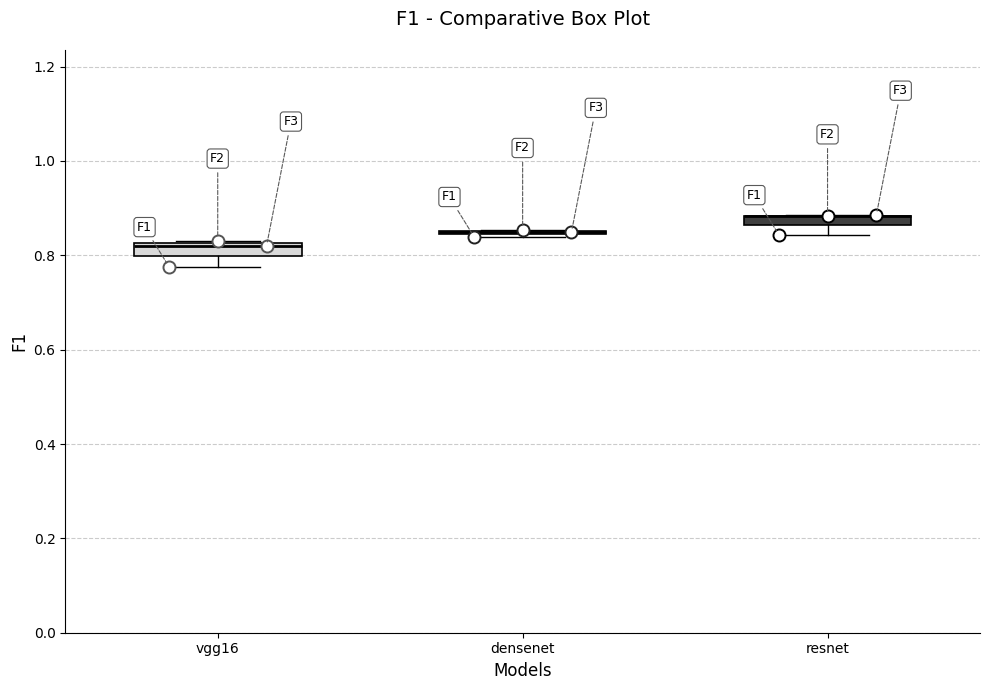

/tmp/ipykernel_640/3828885315.py:253: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


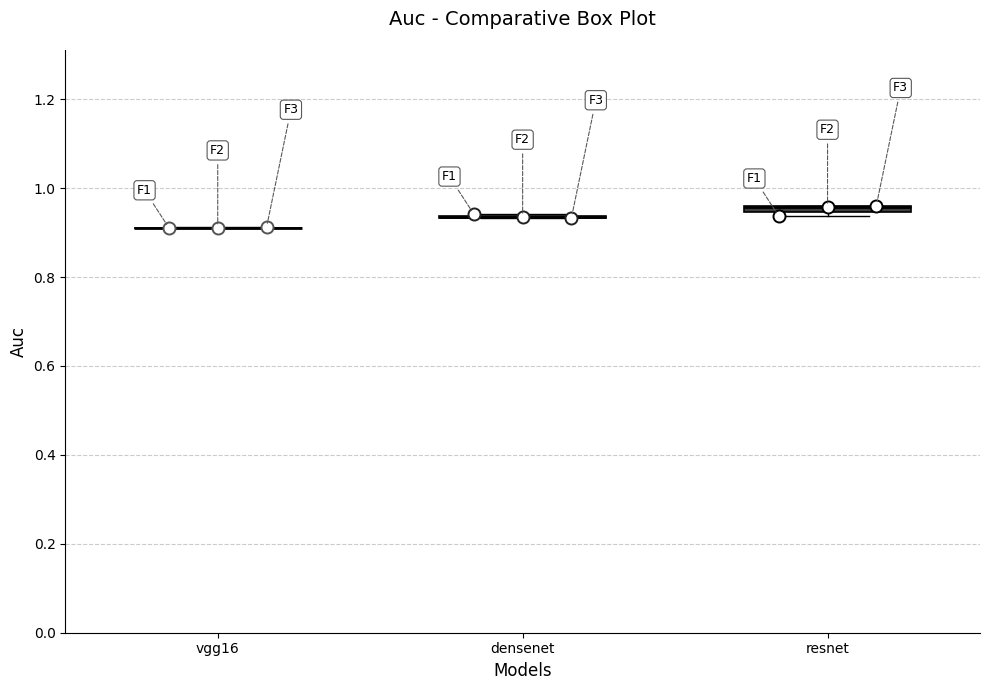

Elaborazione completata.
Grafici salvati in: /content/drive/MyDrive/CrossValidation/Vgg16DensenetOPT/plots/metrics
Tabelle salvate in: /content/drive/MyDrive/CrossValidation/Vgg16DensenetOPT/metrics
Tabelle medie: /content/drive/MyDrive/CrossValidation/Vgg16DensenetOPT/metrics/summary_means_vgg16_densenet_resnet.csv
Tabella completa: /content/drive/MyDrive/CrossValidation/Vgg16DensenetOPT/metrics/complete_summary_vgg16_densenet_resnet_by_fold.csv


In [3]:
# CONFRONTO FINALE: VGG16, DENSENET E RESNET OTTIMIZZATO
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH_RESNETOPT = "/content/drive/MyDrive/CrossValidation/ResnetOPT"

models = ["vgg16", "densenet", "resnet"]
metrics_to_plot = ["accuracy", "sensitivity", "specificity", "f1", "auc"]

paths = {
    "vgg16": os.path.join(BASE_PATH, "metrics", "vgg16_3fold_cv_results.csv"),
    "densenet": os.path.join(BASE_PATH, "metrics", "densenet_3fold_cv_results.csv"),
    "resnet": os.path.join(BASE_PATH_RESNETOPT, "metrics", "resnet_3fold_cv_results.csv")
}

plots_path = os.path.join(BASE_PATH, "plots", "metrics")
metrics_path = os.path.join(BASE_PATH, "metrics")

os.makedirs(plots_path, exist_ok=True)

# Scala di grigi adatta a tesi e stampa
model_colors = {
    "vgg16": "#D9D9D9",
    "densenet": "#969696",
    "resnet": "#404040"
}

point_colors = {
    "vgg16": "#555555",
    "densenet": "#222222",
    "resnet": "#000000"
}


# CARICAMENTO DEI RISULTATI DEI TRE MODELLI

results = {}

for model, path in paths.items():
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"File dei risultati non trovato per {model}:\n{path}"
        )

    df = pd.read_csv(path)

    fold_column = next(
        (
            col for col in ["fold", "Fold", "fold_id", "Fold_ID"]
            if col in df.columns
        ),
        None
    )

    if fold_column is None:
        raise ValueError(
            f"Colonna fold non trovata nel file di {model}."
        )

    if fold_column != "fold":
        df.rename(columns={fold_column: "fold"}, inplace=True)

    missing_metrics = [
        metric for metric in metrics_to_plot
        if metric not in df.columns
    ]

    if missing_metrics:
        raise ValueError(
            f"Metriche mancanti per {model}: {missing_metrics}"
        )

    df["model"] = model
    df = df.sort_values("fold").reset_index(drop=True)
    results[model] = df

complete_df = pd.concat(
    results.values(),
    ignore_index=True
)

complete_df = complete_df[
    ["model", "fold"] + metrics_to_plot +
    [col for col in ["n_train", "n_val", "tn", "fp", "fn", "tp"]
     if col in complete_df.columns]
]


# TABELLA COMPLETA DEI RISULTATI PER FOLD

complete_table = complete_df.copy()

complete_table[metrics_to_plot] = (
    complete_table[metrics_to_plot].round(4)
)

complete_table_path = os.path.join(
    metrics_path,
    "complete_summary_vgg16_densenet_resnet_by_fold.csv"
)

complete_table.to_csv(
    complete_table_path,
    index=False
)

print("TABELLA COMPLETA DEI RISULTATI")
display(complete_table)


# TABELLA RIASSUNTIVA DELLE MEDIE

mean_table = (
    complete_df
    .groupby("model")[metrics_to_plot]
    .mean()
    .reindex(models)
    .round(4)
)

mean_table_path = os.path.join(
    metrics_path,
    "summary_means_vgg16_densenet_resnet.csv"
)

mean_table.to_csv(mean_table_path)

print("TABELLA RIASSUNTIVA DELLE MEDIE")
display(mean_table)


# TABELLA MEDIA E DEVIAZIONE STANDARD

summary_mean_std = (
    complete_df
    .groupby("model")[metrics_to_plot]
    .agg(["mean", "std"])
    .reindex(models)
    .round(4)
)

summary_mean_std_path = os.path.join(
    metrics_path,
    "summary_mean_std_vgg16_densenet_resnet.csv"
)

summary_mean_std.to_csv(summary_mean_std_path)

print("TABELLA MEDIA E DEVIAZIONE STANDARD")
display(summary_mean_std)


# GRAFICI A BARRE DELLE MEDIE

for metric in metrics_to_plot:

    fig, ax = plt.subplots(figsize=(8, 5.5))

    means = [
        mean_table.loc[model, metric]
        for model in models
    ]

    bars = ax.bar(
        models,
        means,
        color=[model_colors[model] for model in models],
        edgecolor="black",
        linewidth=1.2,
        width=0.6
    )

    for bar, value in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    ax.set_title(
        f"{metric.capitalize()} - 3-Fold Cross Validation",
        fontsize=14,
        pad=12
    )

    ax.set_xlabel("Models", fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_ylim(0, 1.05)

    ax.grid(
        axis="y",
        linestyle="--",
        color="0.75",
        alpha=0.8
    )

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    mean_plot_path = os.path.join(
        plots_path,
        f"{metric}_cv_mean_comparison_all_models.png"
    )

    plt.savefig(
        mean_plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# BOX PLOT COMPARATIVO CON PUNTI DEI TRE FOLD

rng = np.random.default_rng(42)

for metric in metrics_to_plot:

    fig, ax = plt.subplots(figsize=(10, 7))

    data_for_boxplot = [
        complete_df.loc[
            complete_df["model"] == model,
            metric
        ].dropna().to_numpy()
        for model in models
    ]

    box = ax.boxplot(
        data_for_boxplot,
        labels=models,
        patch_artist=True,
        widths=0.55,
        showfliers=False,
        medianprops={
            "color": "black",
            "linewidth": 2
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1
        },
        capprops={
            "color": "black",
            "linewidth": 1
        },
        boxprops={
            "edgecolor": "black",
            "linewidth": 1.2
        }
    )

    for patch, model in zip(box["boxes"], models):
        patch.set_facecolor(model_colors[model])
        patch.set_alpha(1)

    # Punti e annotazioni per ogni modello
    for position, model in enumerate(models, start=1):

        model_rows = (
            complete_df[
                complete_df["model"] == model
            ]
            .dropna(subset=[metric])
            .sort_values("fold")
            .reset_index(drop=True)
        )

        fold_values = model_rows[metric].to_numpy()

        # Posizioni orizzontali più distanziate
        jitter = np.linspace(
            -0.16,
            0.16,
            len(fold_values)
        )

        x_points = position + jitter

        ax.scatter(
            x_points,
            fold_values,
            color="white",
            edgecolor=point_colors[model],
            linewidth=1.4,
            s=75,
            zorder=5
        )

        # Offset separati per le etichette F1, F2, F3
        horizontal_offsets = [-0.24, 0.0, 0.24]
        vertical_offsets = [0.07, 0.16, 0.25]

        for i, (x_point, value, (_, row)) in enumerate(
            zip(
                x_points,
                fold_values,
                model_rows.iterrows()
            )
        ):

            x_text = position + horizontal_offsets[i % 3]
            y_text = value + vertical_offsets[i % 3]

            ax.annotate(
                f"F{int(row['fold'])}",
                xy=(x_point, value),
                xytext=(x_text, y_text),
                ha="center",
                va="bottom",
                fontsize=9,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="0.35",
                    linewidth=0.8
                ),
                arrowprops=dict(
                    arrowstyle="-",
                    color="0.35",
                    linewidth=0.8,
                    linestyle="--",
                    shrinkA=3,
                    shrinkB=3
                ),
                zorder=6
            )

    ax.set_title(
        f"{metric.capitalize()} - Comparative Box Plot",
        fontsize=14,
        pad=18
    )

    ax.set_xlabel("Models", fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)

    # Spazio superiore per le annotazioni
    max_value = complete_df[metric].max()
    ax.set_ylim(0, max(1.15, min(1.35, max_value + 0.35)))

    ax.grid(
        axis="y",
        linestyle="--",
        color="0.75",
        alpha=0.8
    )

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    boxplot_path = os.path.join(
        plots_path,
        f"{metric}_cv_boxplot_all_models_with_folds.png"
    )

    plt.savefig(
        boxplot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


print("Elaborazione completata.")
print(f"Grafici salvati in: {plots_path}")
print(f"Tabelle salvate in: {metrics_path}")
print(f"Tabelle medie: {mean_table_path}")
print(f"Tabella completa: {complete_table_path}")